In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [2]:
#Load dataset
df = pd.read_csv('/content/song_recomendation_B.csv')

#Head of dataset
df.head()

,Track URI,Track Name,Artist Name(s),Album Name,Album Release Date,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,spotify:track:6a8GbQIlV8HBUW3c6Uk9PH,I Know You Want Me (Calle Ocho),Pitbull,Pitbull Starring In Rebelution,2009-10-23,64,"dance pop,miami hip hop,pop",0.825,0.743,2.0,-5.995,1.0,0.1490,0.0142,0.000021,0.2370,0.800,127.045,4.0
1,spotify:track:70XtWbcVZcpaOddJftMcVi,From the Bottom of My Broken Heart,Britney Spears,...Baby One More Time (Digital Deluxe Version),1999-01-12,56,"dance pop,pop",0.677,0.665,7.0,-5.171,1.0,0.0305,0.5600,NaN,0.3380,0.706,74.981,4.0
2,spotify:track:72WZtWs6V7uu3aMgMmEkYe,You Can't Always Get What You Want,The Rolling Stones,Let It Bleed,1969-12-05,0,"album rock,british invasion,classic rock,rock",0.319,0.627,0.0,-9.611,1.0,0.0687,0.6750,0.000073,0.2890,0.497,85.818,4.0
3,spotify:track:4bEb3KE4mSKlTFjtWJQBqO,Don't Stop - 2004 Remaster,Fleetwood Mac,Rumours,1977-02-04,79,"album rock,classic rock,rock,soft rock,yacht rock",0.671,0.710,9.0,-7.724,1.0,0.0356,0.0393,0.000011,0.0387,0.834,118.745,4.0
4,spotify:track:0d2iYfpKoM0QCKvcLCkBao,Eastside (with Halsey & Khalid),"benny blanco, Halsey, Khalid",Eastside (with Halsey & Khalid),2018-07-12,78,"pop,electropop,etherpop,indie poptimism,pop,po...",0.560,0.680,6.0,-7.648,0.0,0.3210,0.5550,0.000000,0.1160,0.319,89.391,4.0


In [3]:
df.shape

(4999, 19)

The data consists of 4999 rows and 19 columns.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Track URI           4999 non-null   object 
 1   Track Name          4999 non-null   object 
 2   Artist Name(s)      4999 non-null   object 
 3   Album Name          4999 non-null   object 
 4   Album Release Date  4997 non-null   object 
 5   Popularity          4999 non-null   int64  
 6   Artist Genres       4744 non-null   object 
 7   Danceability        4747 non-null   float64
 8   Energy              4997 non-null   float64
 9   Key                 4997 non-null   float64
 10  Loudness            4997 non-null   float64
 11  Mode                4997 non-null   float64
 12  Speechiness         4997 non-null   float64
 13  Acousticness        4997 non-null   float64
 14  Instrumentalness    4897 non-null   float64
 15  Liveness            4997 non-null   float64
 16  Valenc

# a. Conduct an Exploratory Data Analysis (EDA) on the dataset. Highlight the main insights and any irregularities you find, and address those anomalies appropriately!

## Check Data Problems

In [5]:
#Check duplicate
df.duplicated().sum()

np.int64(13)

There are 13 duplicate rows.

In [6]:
#Handle duplicates
df = df.drop_duplicates()

All duplicate rows are dropped to avoid biased analysis and to not affect clustering.

In [7]:
#Check Inconsistent
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].dropna().unique())


Column: Track URI
['spotify:track:6a8GbQIlV8HBUW3c6Uk9PH'
 'spotify:track:70XtWbcVZcpaOddJftMcVi'
 'spotify:track:72WZtWs6V7uu3aMgMmEkYe' ...
 'spotify:track:6PUzxtIHkv346yP89NzP9X'
 'spotify:track:3kcKlOkQQEPVwxwljbGJ5p'
 'spotify:track:5ydeCNaWDmFbu4zl0roPAH']

Column: Track Name
['I Know You Want Me (Calle Ocho)' 'From the Bottom of My Broken Heart'
 "You Can't Always Get What You Want" ... 'Kernkraft 400'
 'Kernkraft 400 (A Better Day)'
 "Groovejet (If This Ain't Love) [feat. Sophie Ellis-Bextor]"]

Column: Artist Name(s)
['Pitbull' 'Britney Spears' 'The Rolling Stones' ... 'Creeds'
 'Zombie Nation' 'Spiller, Sophie Ellis-Bextor']

Column: Album Name
['Pitbull Starring In Rebelution'
 '...Baby One More Time (Digital Deluxe Version)' 'Let It Bleed' ...
 'Kernkraft 400 Single Mixes' 'Kernkraft 400 (A Better Day)'
 "Groovejet (If This Ain't Love) [feat. Sophie Ellis-Bextor]"]

Column: Album Release Date
['2009-10-23' '1999-01-12' '1969-12-05' ... '2023-03-31' '2006-03-07'
 '2022-06-1

1. Key (musical key) is actually a category, not a number, so it's not suitable to be treated as a numerical value. To avoid incorrect distance calculations, Key is converted to a one-hot format.
2. Mode indicates whether a song is major or minor, so it's already binary data. This feature is still used but standardized so that its contribution is balanced with other features when comparing song similarities.
3. Time Signature (beats per bar) was found to have zero values which are musically meaningless. These values are treated as missing values and imputed with the median, and then this feature is retained and also converted to a one-hot format (same as Key) because of its categorical nature.

In [8]:
#Check Missing Values
df.isna().sum()

,0
Track URI,0
Track Name,0
Artist Name(s),0
Album Name,0
Album Release Date,2
Popularity,0
Artist Genres,255
Danceability,252
Energy,2
Key,2


Columns with Missing Values
1. Album Release Date -> 2 missing
2. Artist Genres -> 255 missing
3. Danceability -> 252 missing
4. Energy -> 2 missing
5. Key -> 2 missing
6. Loudness -> 2 missing
7. Mode -> 2 missing
8. Speechiness -> 2 missing
9. Acousticness -> 2 missing
10. Instrumentalness -> 102 missing
11. Liveness -> 2 missing
12. Valence -> 2 missing
13. Tempo -> 2 missing

In [9]:
#Check Outliers
numeric_cols = [
    "Danceability", "Energy", "Loudness", "Speechiness",
    "Acousticness", "Instrumentalness", "Liveness",
    "Valence", "Tempo"
]

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

    outlier_summary.append({
        'column': col,
        'outlier_count': outliers.shape[0],
        'outlier_min': outliers.min() if not outliers.empty else None,
        'outlier_max': outliers.max() if not outliers.empty else None
    })

outlier_df = pd.DataFrame(outlier_summary)

print(outlier_df[outlier_df['outlier_count'] > 0])

             column  outlier_count  outlier_min  outlier_max
0      Danceability             34      0.00000        0.228
1            Energy             25      0.00002        0.140
2          Loudness            103    -29.36800      -15.366
3       Speechiness            557      0.11800        0.711
4      Acousticness            231      0.78100        0.987
5  Instrumentalness            999      0.00134        0.973
6          Liveness            239      0.47700        0.982
8             Tempo            116      0.00000      213.654


1. Danceability (34 outliers, 0.000-0.228): Very low values indicate songs are not very "danceable". This could be the song's character or erroneous data, requiring a check.
2. Energy (25 outliers, 0.00002-0.140): Very low energy usually means the song is very soft or has minimal dynamics. This can be valid, but also potentially an error, so it needs to be checked.
3. Loudness (103 outliers, -29.368-(-15.039)): Very low loudness values indicate a very quiet sound. Since there are many outliers, handling them should be considered.
4. Speechiness (557 outliers, 0.118-0.711): High values mean a lot of spoken words (e.g., podcasts or rap). Given the large number of outliers, this could affect clustering results.
5. Acousticness (231 outliers, 0.781-0.987): Indicates very acoustic songs. This can be valid, but since there are many outliers, it needs to be checked.
6. Instrumentalness (999 outliers, 0.00134-0.973): A very large number of outliers, indicating many instrumental songs or inconsistent data. Needs to be handled to avoid affecting the model.
7. Liveness (239 outliers, 0.474-0.982): High values indicate live recordings (concerts). This can be valid, but still needs to be checked due to the significant number of outliers.
8. Tempo (116 outliers, 0.000–213.654): A tempo of 0 is clearly unrealistic, and very high tempos are also rare. Thus, it needs to be addressed.

## Distribution & Outlier Visualization

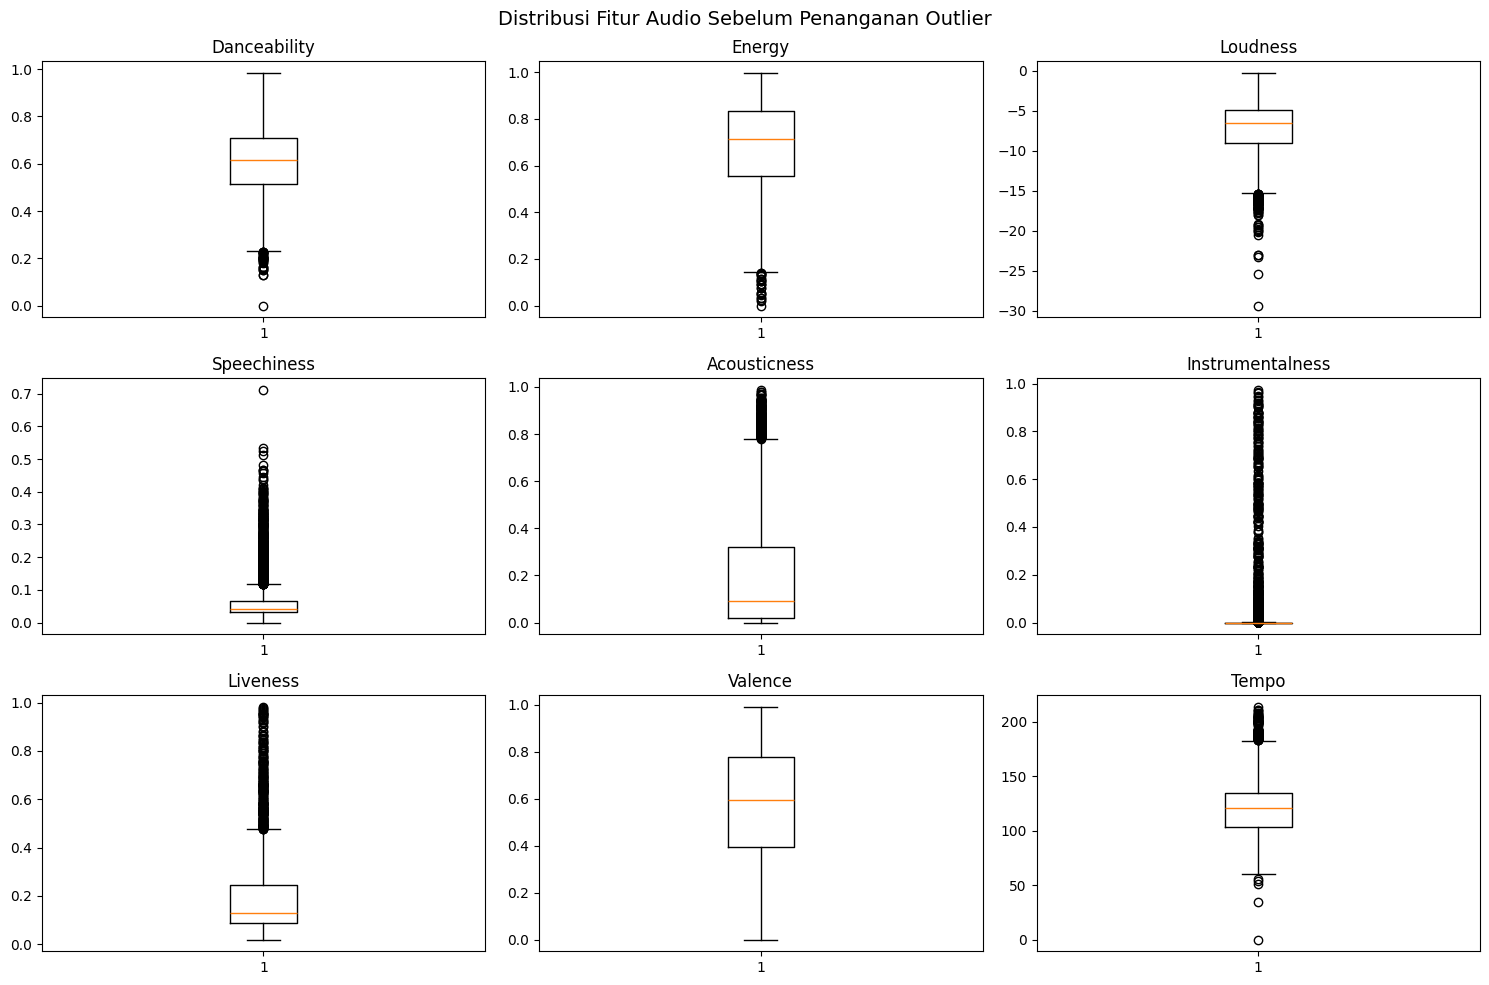

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
plt.suptitle("Distribusi Fitur Audio Sebelum Penanganan Outlier", fontsize=14)
plt.tight_layout()
plt.show()


## Handle Data Problems

In [11]:
#Handle irrelevant value: 0 in Time Signature is musically invalid
df["Time Signature"] = df["Time Signature"].replace(0, np.nan)
df["Time Signature"].fillna(df["Time Signature"].median(), inplace=True)


A value of 0 for Time Signature is musically invalid, so it is replaced with a missing value to avoid affecting analysis, then imputed with the median to maintain data completeness.

In [12]:
#Handle Missing Value
df = df.dropna()

Missing values are dropped because filling missing values in important audio features can make the data unrealistic, while the dataset is still large enough that losing a few rows is not an issue.

In [13]:
#Recheck outliers on the cleaned data (after dropna & Time Signature fix, before capping)
outlier_summary_clean = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

    outlier_summary_clean.append({
        'column': col,
        'outlier_count': outliers.shape[0],
        'outlier_min': outliers.min() if not outliers.empty else None,
        'outlier_max': outliers.max() if not outliers.empty else None
    })

outlier_df_clean = pd.DataFrame(outlier_summary_clean)

print(outlier_df_clean[outlier_df_clean['outlier_count'] > 0])


             column  outlier_count  outlier_min  outlier_max
0      Danceability             33      0.00000        0.232
1            Energy             26      0.00002        0.149
2          Loudness            104    -29.36800      -15.039
3       Speechiness            501      0.11800        0.711
4      Acousticness            239      0.75600        0.987
5  Instrumentalness            912      0.00112        0.973
6          Liveness            209      0.47600        0.982
8             Tempo            114      0.00000      213.654


The number of outliers above is re-calculated after duplicate data, missing values, and invalid `Time Signature` values are cleaned, so the numbers are consistent with the data that will actually be capped in the next step (the numbers in the initial outlier check during EDA were still calculated from raw data, before cleaning).

In [14]:
#Snapshot features before capping, used for before vs after comparison plots
_capping_cols = ["Danceability", "Energy", "Loudness", "Speechiness",
                 "Acousticness", "Instrumentalness", "Liveness", "Tempo"]
df_before_capping = df[_capping_cols].copy()


In [15]:
#Handle Outliers Use IQR Capping
outlier_cols = [
    "Danceability", "Energy", "Loudness", "Speechiness",
    "Acousticness", "Instrumentalness", "Liveness", "Tempo"
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # cap values
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])


### Before vs After Capping

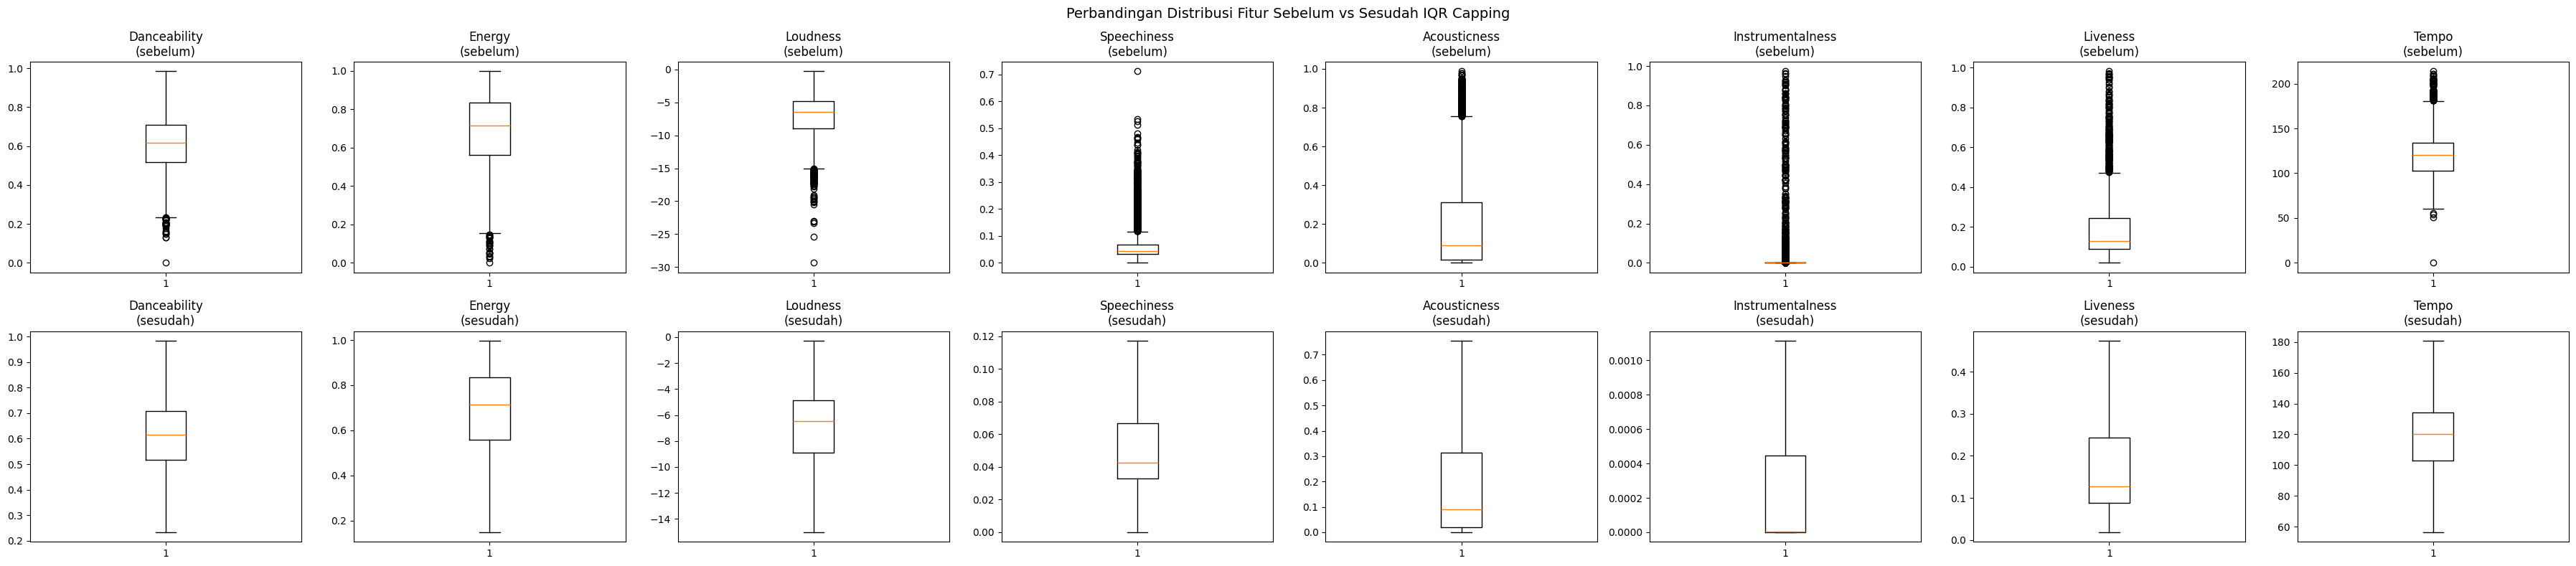

In [16]:
fig, axes = plt.subplots(2, len(outlier_cols), figsize=(36, 8))
for i, col in enumerate(outlier_cols):
    axes[0, i].boxplot(df_before_capping[col])
    axes[0, i].set_title(f"{col}\n(sebelum)")
    axes[1, i].boxplot(df[col])
    axes[1, i].set_title(f"{col}\n(sesudah)")
plt.suptitle("Perbandingan Distribusi Fitur Sebelum vs Sesudah IQR Capping", fontsize=14)
plt.tight_layout()
plt.show()

Outliers in audio features can be valid because some songs indeed have extreme characteristics (e.g., instrumental or live), but these extreme values can disrupt similarity calculations between songs in a content-based recommendation system because audio feature distributions are usually not normal. IQR capping is safer than z-score, and this method preserves data by only limiting extreme values without deleting data.

In [17]:
#One Hot Encoding
from sklearn.preprocessing import OneHotEncoder

df["Key"] = df["Key"].astype("Int64")
df["Time Signature"] = df["Time Signature"].astype("Int64")

ohe = OneHotEncoder(handle_unknown="ignore",sparse_output=False)

encoded = ohe.fit_transform(df[["Key", "Time Signature"]])
encoded_cols = ohe.get_feature_names_out(["Key", "Time Signature"])
encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=df.index)

df = pd.concat([df.drop(columns=["Key", "Time Signature"]), encoded_df], axis=1)

Key and Time Signature variables are essentially categories, not numbers that have an order or distance. If left as numbers, the model might assume, for example, that Key 1 is "closer" to Key 2 than Key 11, whereas musically, this is not the case. One Hot Encoding transforms each category into a separate column so that the model does not assume any order or distance between categories, making similarity calculations or predictive models more accurate.

In [18]:
#Scaling
from sklearn.preprocessing import StandardScaler

num_cols = ["Danceability", "Energy", "Loudness", "Speechiness",
            "Acousticness", "Instrumentalness", "Liveness",
            "Valence", "Tempo"]

scaler = StandardScaler()
scaler.fit(df[num_cols])


StandardScaler()

Scaling is performed so that all audio features have the same scale, preventing features with a large range of values from dominating when calculating similarity or when used in a model. StandardScaler is chosen because it transforms data into a distribution with a mean of 0 and a standard deviation of 1, making it suitable for features with different scales and distributions like danceability, loudness, and tempo.

## Additional Visualizations

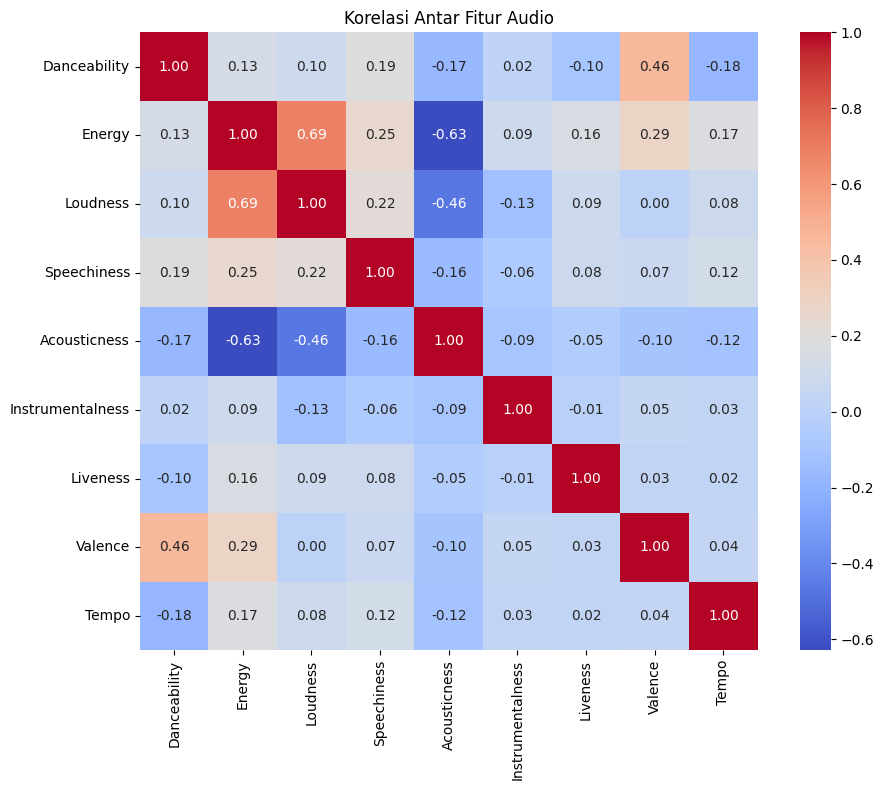

In [19]:
import seaborn as sns

plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Korelasi Antar Fitur Audio")
plt.tight_layout()
plt.show()


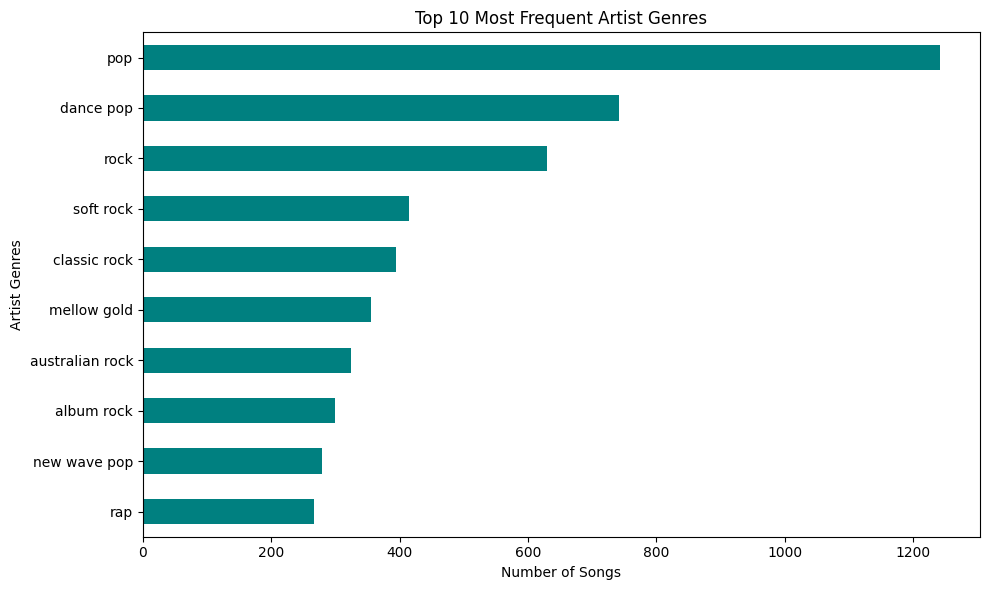

In [20]:
#Top 10 most frequent artist genres (Artist Genres column split by comma)
genre_series = df["Artist Genres"].dropna().str.split(",").explode().str.strip()
top_genres = genre_series[genre_series != ""].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_genres.sort_values().plot(kind="barh", color="teal")
plt.title("Top 10 Most Frequent Artist Genres")
plt.xlabel("Number of Songs")
plt.tight_layout()
plt.show()


# b. Create a content-based recommendation system, implemented as a function that takes a text input and returns five suggested items!

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#Text Feature
df["text_feature"] = df["Track Name"] + " " + df["Artist Name(s)"] + " " + df["Artist Genres"]

#TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df["text_feature"])

In [22]:
#Keyword Detection + threshold
def detect_keywords(text):
    text = text.lower()
    return {
        "fast": any(k in text for k in ["fast", "quick"]),
        "slow": any(k in text for k in ["slow", "calm", "relax", "chill"]),
        "dance": any(k in text for k in ["dance", "edm", "club"]),
        "energetic": any(k in text for k in ["energetic", "powerful", "upbeat"]),
        "acoustic": "acoustic" in text,
        "instrumental": "instrumental" in text,
        "rap": any(k in text for k in ["rap", "spoken", "hip hop"]),
        "happy": any(k in text for k in ["happy", "joy", "fun"]),
        "sad": any(k in text for k in ["sad", "melancholy", "emotional"]),
        "live": "live" in text
    }

def apply_threshold(df, keywords):
    mask = pd.Series(True, index=df.index)

    if keywords["fast"]:
        mask &= df["Tempo"] > 120
    if keywords["slow"]:
        mask &= df["Tempo"] < 90
    if keywords["dance"]:
        mask &= df["Energy"] > 0.6
    if keywords["energetic"]:
        mask &= df["Energy"] > 0.75
    if keywords["acoustic"]:
        mask &= df["Acousticness"] > 0.6
    if keywords["instrumental"]:
        mask &= df["Instrumentalness"] > 0.6
    if keywords["rap"]:
        mask &= df["Speechiness"] > 0.4
    if keywords["happy"]:
        mask &= df["Valence"] > 0.6
    if keywords["sad"]:
        mask &= df["Valence"] < 0.4
    if keywords["live"]:
        mask &= df["Liveness"] > 0.5

    return mask

In [23]:
#Audio profile targets used to score candidates against the input.
#Targets are given in RAW feature units (the same units/scale the
#dataset itself uses, e.g. Energy 0-1, Tempo in BPM) so each value is
#interpretable and stays within the feature's real range. They are
#then converted to the standardized space with the SAME scaler used
#for the candidates -- comparing them directly as hand-picked z-scores
#would be inconsistent (e.g. a manually guessed z of 1.5 for a 0-1
#bounded feature like Energy can fall outside what any real song can
#have, since Energy's std is much smaller than 1).
KEYWORD_AUDIO_PROFILE_RAW = {
    "fast": {"Tempo": 150},
    "slow": {"Tempo": 75},
    "dance": {"Energy": 0.85},
    "energetic": {"Energy": 0.9, "Valence": 0.75},
    "acoustic": {"Acousticness": 0.85, "Energy": 0.25},
    "instrumental": {"Instrumentalness": 0.85},
    "rap": {"Speechiness": 0.6},
    "happy": {"Valence": 0.85},
    "sad": {"Valence": 0.2},
    "live": {"Liveness": 0.75},
}

#Genre keyword targets used to filter candidates by the "Artist Genres" text,
#so genre keywords constrain the genre and not just the audio thresholds
GENRE_KEYWORDS = {
    "dance": ["dance", "edm", "house", "electro", "club"],
    "acoustic": ["acoustic"],
    "instrumental": ["instrumental"],
    "rap": ["rap", "hip hop", "grime"],
    "live": ["live"],
}

def recommend(text_input, top_n=5, text_weight=0.5):
    keywords = detect_keywords(text_input)

    mask = apply_threshold(df, keywords)
    filtered_df = df[mask].copy()

    #--- Genre keyword matching ---
    #Require the Artist Genres text to match too, as long as enough
    #candidates remain (otherwise fall back to the unfiltered set below)
    genre_terms = []
    for kw, active in keywords.items():
        if active:
            genre_terms.extend(GENRE_KEYWORDS.get(kw, []))

    if genre_terms:
        genre_lower = filtered_df["Artist Genres"].fillna("").str.lower()
        genre_mask = genre_lower.apply(lambda g: any(term in g for term in genre_terms))
        if genre_mask.sum() >= top_n:
            filtered_df = filtered_df[genre_mask]

    #--- Remove duplicate tracks ---
    #Drops near-duplicate rows (e.g. remasters/re-releases) so the same
    #song can't appear twice in one set of recommendations
    filtered_df = filtered_df.drop_duplicates(subset=["Track Name", "Artist Name(s)"])

    # Handle case where no songs match after filtering
    if filtered_df.empty:
        return pd.DataFrame(columns=["Track Name", "Artist Name(s)", "Artist Genres"])

    #--- Text similarity ---
    #Reuse the globally fitted TF-IDF vectorizer so the query and the
    #candidates share the same vocabulary/IDF space
    tfidf_matrix_filtered = tfidf.transform(filtered_df["text_feature"])
    input_vec = tfidf.transform([text_input])
    text_sim = cosine_similarity(input_vec, tfidf_matrix_filtered).flatten()

    #--- Audio similarity ---
    #Build a target audio profile from the keywords detected in the input
    #text, then compare each candidate song to that profile. The target
    #starts at the dataset's own mean for every feature the input does
    #not touch (a "neutral" song), and is overridden with a raw-unit
    #value for whichever features the detected keywords do touch.
    audio_scaled_filtered = scaler.transform(filtered_df[num_cols])

    target_raw = scaler.mean_.copy()
    touched = False
    for kw, active in keywords.items():
        if not active:
            continue
        for feature, target_value in KEYWORD_AUDIO_PROFILE_RAW.get(kw, {}).items():
            target_raw[num_cols.index(feature)] = target_value
            touched = True

    if touched:
        target_scaled = scaler.transform(target_raw.reshape(1, -1))
        audio_sim = cosine_similarity(target_scaled, audio_scaled_filtered).flatten()
    else:
        #No audio-related keyword detected -> no audio target to compare
        #against, so rely on text similarity only
        audio_sim = np.zeros(len(filtered_df))
        text_weight = 1.0

    combined_scores = text_weight * text_sim + (1 - text_weight) * audio_sim

    top_indices = combined_scores.argsort()[-top_n:][::-1]

    return filtered_df.iloc[top_indices][["Track Name", "Artist Name(s)", "Artist Genres"]]


# c. Provide a minimum of three inputs to the function and examine if the recommendations correspond to each input!

In [24]:
inputs = [
    "energetic dance pop",
    "calm acoustic guitar",
    "upbeat EDM track",
    "fast tempo dance track",
    "piano instrumental"
]

from IPython.display import display, Markdown

for i, inp in enumerate(inputs, 1):
    display(Markdown(f"### 🎧 Input {i}: *{inp}*"))

    rec = recommend(inp, top_n=5).reset_index(drop=True)
    rec.index += 1
    rec = rec.rename(columns={
        "Track Name": "Track",
        "Artist Name(s)": "Artist",
        "Artist Genres": "Genres"
    })

    display(rec)


### 🎧 Input 1: *energetic dance pop*

,Track,Artist,Genres
1,Lonely,Joel Corry,"dance pop,pop dance,uk dance"
2,Give It 2 Me,Madonna,"dance pop,pop"
3,Promiscuous,"Nelly Furtado, Timbaland","canadian latin,canadian pop,dance pop,pop,danc..."
4,In Your Eyes,Kylie Minogue,"australian dance,australian pop,dance pop,euro..."
5,Came Here for Love,"Sigala, Ella Eyre","dance pop,edm,pop dance,uk dance,uk pop,dance ..."


### 🎧 Input 2: *calm acoustic guitar*

,Track,Artist,Genres
1,I'll Be There for You (Friends Theme),Boyce Avenue,"acoustic cover,neo mellow,viral pop"
2,Please Don't Say You Love Me,Gabrielle Aplin,"acoustic pop,neo-singer-songwriter,uk pop,vira..."
3,This City,Sam Fischer,"australian pop,singer-songwriter pop"
4,Walking To New Orleans - Remastered,Fats Domino,"louisiana blues,new orleans blues,piano blues,..."
5,When I Was Your Man,Bruno Mars,"dance pop,pop"


### 🎧 Input 3: *upbeat EDM track*

,Track,Artist,Genres
1,"This Is It - 7"" Version",Dannii Minogue,"australian dance,australian pop,europop,talent..."
2,Too Many Broken Hearts,Jason Donovan,"australian dance,australian pop,new wave pop"
3,Better Best Forgotten,Steps,"diva house,europop,talent show"
4,Promiscuous,"Nelly Furtado, Timbaland","canadian latin,canadian pop,dance pop,pop,danc..."
5,New Sensation,INXS,"australian rock,dance rock,funk rock,new roman..."


### 🎧 Input 4: *fast tempo dance track*

,Track,Artist,Genres
1,Can You Forgive Her? - 2001 Remastered Version,Pet Shop Boys,"dance rock,new romantic,new wave,new wave pop,..."
2,Magic Number,"The Potbelleez, B.o.B","aussietronica,australian dance,australian hous..."
3,Twist of Fate,Olivia Newton-John,"adult standards,australian dance,disco,mellow ..."
4,Objection (Tango),Shakira,"colombian pop,dance pop,latin pop,pop"
5,Army of Two,Olly Murs,"dance pop,pop,talent show"


### 🎧 Input 5: *piano instrumental*

,Track,Artist,Genres


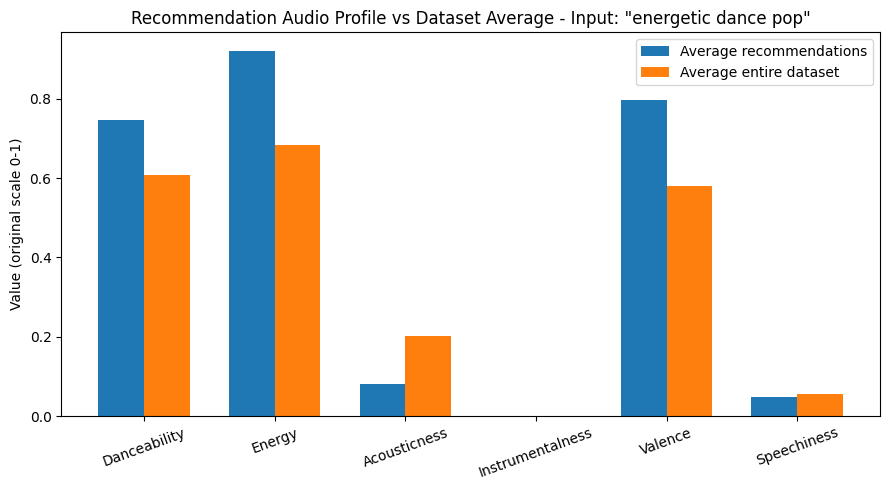

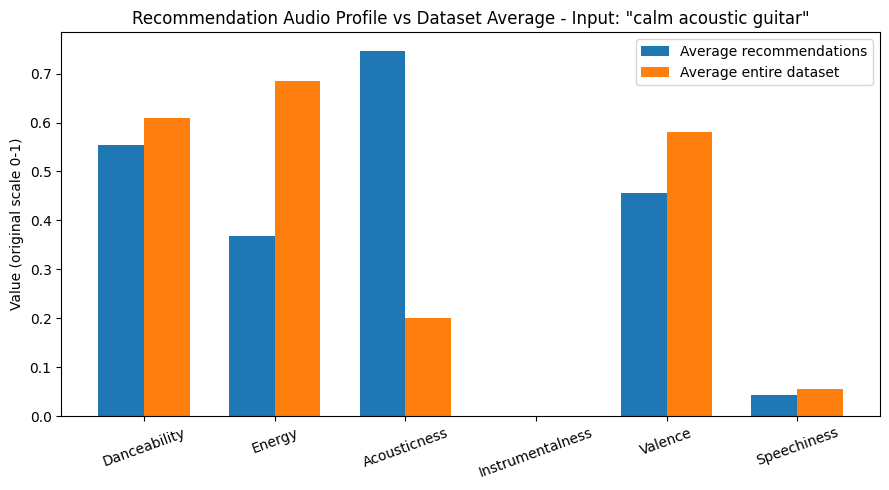

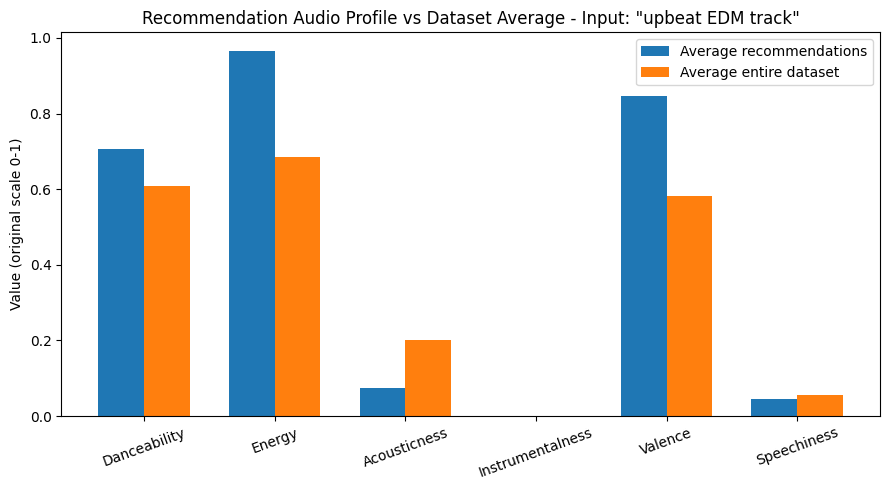

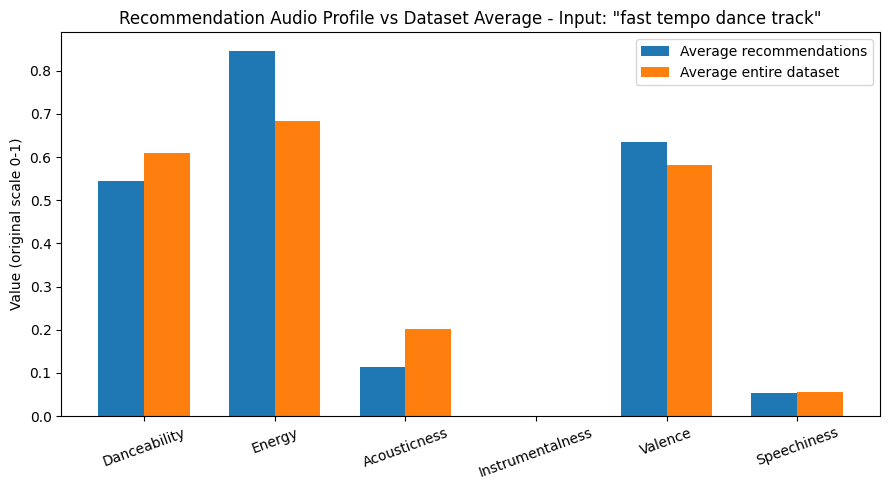

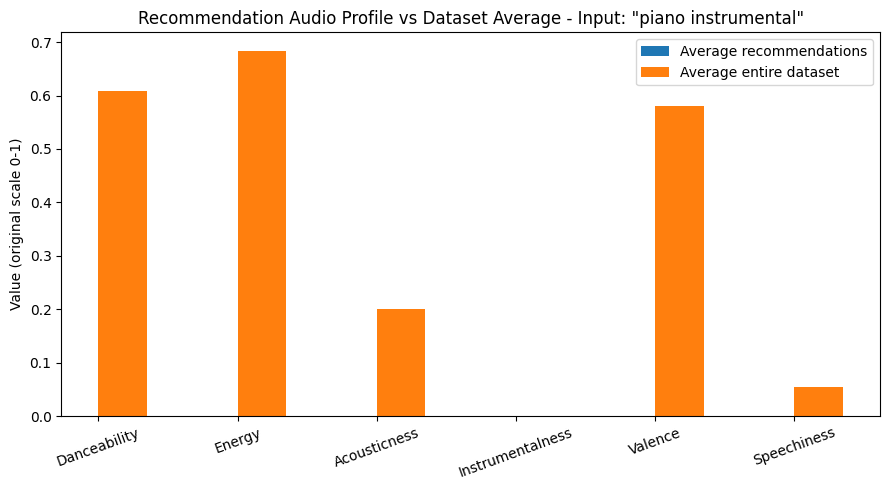

In [26]:
def plot_recommendation_profile(rec_pairs, feature_cols=None, title=""):
    """
    Bar chart comparing the average audio features (raw scale, before
    standardization) of recommended songs against the average of the
    entire dataset, to show why those songs are relevant to the given
    input.

    rec_pairs: list of (Track Name, Artist Name(s)) tuples -- matching on
    both columns (not just Track Name) avoids pulling in the wrong rows
    when a different artist happens to share the same track title.
    """
    if feature_cols is None:
        feature_cols = ["Danceability", "Energy", "Acousticness",
                             "Instrumentalness", "Valence", "Speechiness"]

    rec_key = list(zip(df["Track Name"], df["Artist Name(s)"]))
    mask = [pair in set(rec_pairs) for pair in rec_key]
    rec_rows = df[mask]
    rec_mean = rec_rows[feature_cols].mean()
    overall_mean = df[feature_cols].mean()

    x = np.arange(len(feature_cols))
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - width/2, rec_mean, width, label="Average recommendations")
    plt.bar(x + width/2, overall_mean, width, label="Average entire dataset")
    plt.xticks(x, feature_cols, rotation=20)
    plt.ylabel("Value (original scale 0-1)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

for inp in inputs:
    rec = recommend(inp, top_n=5)
    plot_recommendation_profile(
        list(zip(rec["Track Name"], rec["Artist Name(s)"])),
        title=f'Recommendation Audio Profile vs Dataset Average - Input: "{inp}"'
    )

## Conclusion

**Limitations Note:** Audio features like `Instrumentalness` in this dataset can sometimes be inaccurate for certain genres (e.g., rap/grime), because speech/rap vocals are sometimes still detected as "instrumental" by the original feature extraction algorithm. As a result, keyword filters like "instrumental" or "piano" might pass songs whose genre contains the word "instrumental" but actually still contain vocals. This is a limitation of the data/features themselves, not of the filtering logic, and therefore needs to be considered when interpreting recommendation results.

The music recommendation system is built using a content-based recommendation approach by leveraging text similarity and the audio characteristics of each song. User input descriptions are converted into vector representations using TF-IDF, and then their similarity to song data is calculated using cosine similarity.

To enhance the relevance of recommendation results, the system also implements a filtering process based on keywords in user input, such as dance, acoustic, EDM, fast tempo, and instrumental. These keywords are used to filter songs based on audio features (e.g., energy, tempo, acousticness, and instrumentalness) as well as genres, so that songs inconsistent with the context can be eliminated.

With the combination of text similarity, audio similarity, and keyword- and genre-based filtering, this system is capable of providing music recommendations that are relevant and consistent with user preferences expressed through free-text descriptions.